# 💡 Thuật toán K-means clustering - Unsupervised Learning
## ☕ Ý tưởng cốt lõi
- Với thuật toán K-means clustering, nhãn của từng điểm dữ liệu không được biết trước (chỉ biết $\mathbf{X}$) ➡ Mục tiêu là làm thế nào để phân dữ liệu thành các cụm (**cluster** - tập hợp các điểm có vector đặc trưng gần nhau) khác nhau sao cho dữ liệu trong cùng một cụm có tính chất giống nhau
- Ví dụ: Phân loại khách hàng dựa trên hành vi mua sắm

- Lãnh hải là vùng lãnh địa của mỗi cluster, phân chia nhau bởi đường trung trực của centers các cluster


## ☕ Phân tích toán học & Tối ưu tính toán

- Tập dữ liệu train: $X\in\mathbb{R}^{N \times d}$ trong đó $x_i\in\mathbb{R}^{d}$

- Centroid clusters: $M\in\mathbb{R}^{K\times d}$

- Label giả sử của các điểm: $y\in\mathbb{R}^{N\times K}$ với các hàng là các vector *One hot-coding*

$$y_{ij} \in \{0, 1\}, \quad \forall i, j; \quad \sum_{j=1}^{K} y_{ij} = 1, \quad \forall i$$

## ❗ Chú ý:
- Ban đầu tập dữ liệu không có label ở đây ta giả sử label

## ⚡ Hàm mất mát:

- Xét một điểm mới giả sử được phân vào cluster $k$ nếu điều này là đúng thì ta mong muốn điểm $x_i$ sẽ có khoảng cách gần nhất với cluster $k$ khi so sánh với các cluster khác $$y_{ik} = 1, \quad y_{ij} = 0, \quad \forall j \neq k$$

$$\|\mathbf{x}_i - \mathbf{m}_k\|_2^2 = y_{ik} \|\mathbf{x}_i - \mathbf{m}_k\|_2^2 = \sum_{j=1}^{K} y_{ij} \|\mathbf{x}_i - \mathbf{m}_j\|_2^2$$

- Do đó sai số trung bình cho toàn bộ dữ liệu là:

$$\mathcal{L}(\mathbf{Y}, \mathbf{M}) = \frac{1}{N} \sum_{i=1}^{N} \sum_{j=1}^{K} y_{ij} \|\mathbf{x}_i - \mathbf{m}_j\|_2^2$$

- Mục tiêu là tối ưu hàm này để tìm center và label cho cluster

$$\mathbf{Y}, \mathbf{M} = \arg\min_{\mathbf{Y}, \mathbf{M}} \frac{1}{N} \sum_{i=1}^{N} \sum_{j=1}^{K} y_{ij} \|\mathbf{x}_i - \mathbf{m}_j\|_2^2$$

$$\text{Với: } y_{ij} \in \{0, 1\}, \quad \forall i, j; \quad \sum_{j=1}^{K} y_{ij} = 1, \quad \forall i$$


## ⚡ Tối ưu hàm mất mát:

- Do đây là bài toán tối ưu có ràng buộc điều kiện việc giải nghiệm toàn cục rất khó. Tuy nhiên có thể giải nghiệm gần đúng với kỹ thuật xen kẽ giải Y và M trong khi một biến còn lại cố định tới khi hàm mất mát hội tụ

### ♒ Cố định **M** và tìm **Y**

- Giả sử đã tìm các centroid của cluster, hãy tìm các label vector đề hàm mất mát đạt giá trị nhỏ nhất. Điều này tương đương với việc tìm cluster cho mỗi điểm dữ liệu

$$\mathbf{y}_i = \arg\min_{\mathbf{y}_i} \frac{1}{N} \sum_{j=1}^{K} y_{ij} \|\mathbf{x}_i - \mathbf{m}_j\|_2^2$$

$$\text{Với: } y_{ij} \in \{0, 1\}, \quad \forall i, j; \quad \sum_{j=1}^{K} y_{ij} = 1, \quad \forall i$$

- Do chỉ có một phần tử của label vector $y_i$ bằng 1 nên bài toán chuyển thành tìm centroid gần điểm $x_i$ nhất:

$$j = \arg\min_j \|\mathbf{x}_i - \mathbf{m}_j\|_2^2$$

### ♒ Cố định **Y** và tìm **M**

- Giả sử đã tìm được cluster cho từng điểm, hãy tìm centroid mới cho mỗi cluster để hàm mất mát đạt giá trị nhỏ nhất

$$\mathbf{m}_j = \arg\min_{\mathbf{m}_j} \frac{1}{N} \sum_{i=1}^{N} y_{ij} \|\mathbf{x}_i - \mathbf{m}_j\|_2^2$$

- Đặt $l(m_i)$ = $\frac{1}{N} \sum_{i=1}^{N} y_{ij} \|\mathbf{x}_i - \mathbf{m}_j\|_2^2$

- Đạo hàm giải phương trình:

$$\nabla_{\mathbf{m}_j} l(\mathbf{m}_j) = \frac{2}{N} \sum_{i=1}^{N} y_{ij} (\mathbf{m}_j - \mathbf{x}_i) = \mathbf{0} \iff \mathbf{m}_j \sum_{i=1}^{N} y_{ij} = \sum_{i=1}^{N} y_{ij} \mathbf{x}_i \iff \mathbf{m}_j = \frac{\sum_{i=1}^{N} y_{ij} \mathbf{x}_i}{\sum_{i=1}^{N} y_{ij}}$$

- Nhận thấy mẫu chính là số lượng các điểm trong cluster j còn tử là tổng các điểm dữ liệu trong cluster j

--> $m_j$ là trung bình cộng (mean) của các điểm trong cluster j

## Thuật toán K-means clustering:

1. Chọn K điểm bất kỳ trong training set làm các centroid ban đầu.
2. Phân mỗi điểm dữ liệu vào cluster có centroid gần nó nhất.
3. Nếu việc phân nhóm dữ liệu vào từng cluster bước 2 không thay đổi so với vòng
lặp trước nó thì ta dừng thuật toán.
4. Cập nhật centroid cho từng cluster bằng cách lấy trung bình cộng của tất cả các
điểm dữ liệu đã được gán vào cluster đó sau bước 2.
5. Quay lại bước 2.







## Implement Scratch

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


class KMeansClustering:
    """
    K-means Clustering từ đầu (from scratch).

    Parameters
    ----------
    X : np.ndarray, shape (N, d)
        Tập dữ liệu huấn luyện. N điểm, mỗi điểm d chiều.
    n_clusters : int
        Số cluster K cần tìm.
    random_state : int, optional
        Seed để tái tạo kết quả (mỗi lần chạy cho kết quả như nhau).
    """

    def __init__(self, X, n_clusters, random_state=None):
        # Chuyển về float64 để tránh overflow khi tính bình phương
        self.X = np.asarray(X, dtype=np.float64)
        self.n_clusters = n_clusters          # K
        self.n_samples = self.X.shape[0]      # N
        self.n_features = self.X.shape[1]     # d

        # Kết quả sẽ lưu ở đây sau khi fit
        self.centroids = None                 # shape (K, d)
        self.labels_ = None                   # shape (N,)   - nhãn cuối cùng
        self.inertia_ = None                  # float        - giá trị loss WCSS
        self.n_iter_ = 0                      # int          - số vòng lặp thực tế

        # Random generator để tái tạo
        self.rng = np.random.default_rng(random_state)

    # ------------------------------------------------------------------
    # Bước 1: Khởi tạo centroid (chọn K điểm ngẫu nhiên từ dữ liệu)
    # ------------------------------------------------------------------
    def _initialize_centroids(self):
        """
        Chọn K điểm bất kỳ từ X làm centroid ban đầu.
        """
        indices = self.rng.choice(
            self.n_samples,
            size=self.n_clusters,
            replace=False          # Đảm bảo K điểm không trùng nhau
        )
        self.centroids = self.X[indices].copy()   # shape (K, d)
        return self.centroids

    # ------------------------------------------------------------------
    # Bước 2: Tính khoảng cách Euclidean từ MỌI điểm đến MỌI centroid
    # ------------------------------------------------------------------
    def _compute_distances(self, X):
        """
        Tính khoảng cách Euclidean ||x_i - m_j||_2.

        Parameters
        ----------
        X : np.ndarray, shape (M, d)
            Dữ liệu cần tính khoảng cách (có thể là X_train hoặc X_new).

        Returns
        -------
        distances : np.ndarray, shape (M, K)
            distances[i, j] = khoảng cách từ điểm i đến centroid j.
        """
        # Kỹ thuật broadcasting:
        #   X[:, None, :]  -> (M, 1, d)
        #   centroids[None, :, :] -> (1, K, d)
        #   diff -> (M, K, d) -> bình phương -> tổng theo axis=2 -> căn bậc 2
        diff = X[:, None, :] - self.centroids[None, :, :]   # (M, K, d)
        distances = np.sqrt(np.sum(diff ** 2, axis=2))      # (M, K)
        return distances

    # ------------------------------------------------------------------
    # Bước 3: Assignment - Gán mỗi điểm vào cluster gần nhất
    # ------------------------------------------------------------------
    def _assign_labels(self, X):
        """
        Gán nhãn y_i = argmin_j ||x_i - m_j||^2.

        Returns
        -------
        labels : np.ndarray, shape (M,)
            Nhãn cluster (0, 1, ..., K-1) của từng điểm.
        """
        distances = self._compute_distances(X)      # (M, K)
        labels = np.argmin(distances, axis=1)       # (M,)
        return labels

    # ------------------------------------------------------------------
    # Bước 4: Update - Tính centroid mới = mean của các điểm trong cluster
    # ------------------------------------------------------------------
    def _update_centroids(self, X, labels):
        """
        Cập nhật m_j = (1/|C_j|) * sum(x_i) với x_i thuộc C_j.

        Xử lý edge case: nếu cluster j rỗng (không có điểm nào),
        giữ nguyên centroid cũ (hoặc có thể khởi tạo lại ngẫu nhiên).
        """
        for j in range(self.n_clusters):
            # Lấy các điểm thuộc cluster j
            points_in_cluster = X[labels == j]      # shape (n_j, d)

            if len(points_in_cluster) > 0:
                # Centroid mới = trung bình cộng
                self.centroids[j] = np.mean(points_in_cluster, axis=0)
            else:
                # Cluster rỗng: giữ nguyên centroid cũ
                # (Có thể cải tiến bằng cách chọn điểm xa nhất)
                pass

    # ------------------------------------------------------------------
    # Bước 5: Tính hàm mất mát (WCSS / Inertia)
    # ------------------------------------------------------------------
    def _compute_inertia(self, X, labels):
        """
        Tính tổng bình phương khoảng cách từ mỗi điểm đến centroid của nó.

        loss = sum_{i=1}^{N} ||x_i - m_{y_i}||^2
        """
        inertia = 0.0
        for j in range(self.n_clusters):
            mask = (labels == j)
            if np.any(mask):
                # Tổng khoảng cách bình phương đến centroid j
                diff = X[mask] - self.centroids[j]      # (n_j, d)
                inertia += np.sum(diff ** 2)
        return inertia

    # ------------------------------------------------------------------
    # Bước 6: Fit - Chạy vòng lặp Assignment -> Update cho đến hội tụ
    # ------------------------------------------------------------------
    def fit(self, max_iters=100, tol=1e-4, verbose=False):
        """
        Chạy thuật toán K-means.

        Parameters
        ----------
        max_iters : int
            Số vòng lặp tối đa.
        tol : float
            Ngưỡng dừng: nếu centroid dịch chuyển < tol thì dừng.
        verbose : bool
            Nếu True, in ra loss mỗi vòng lặp.
        """
        # 6a. Khởi tạo
        self._initialize_centroids()

        for iteration in range(1, max_iters + 1):
            # 6b. Assignment: gán nhãn
            labels = self._assign_labels(self.X)

            # 6c. Lưu centroid cũ để so sánh hội tụ
            old_centroids = self.centroids.copy()

            # 6d. Update: tính centroid mới
            self._update_centroids(self.X, labels)

            # 6e. Tính loss
            loss = self._compute_inertia(self.X, labels)

            if verbose:
                print(f"Iter {iteration:3d} | Inertia: {loss:.4f}")

            # 6f. Kiểm tra hội tụ: nếu centroid hầu như không đổi
            centroid_shift = np.linalg.norm(self.centroids - old_centroids)
            if centroid_shift < tol:
                if verbose:
                    print(f"--> Hội tụ sau {iteration} vòng lặp.")
                break

        # Lưu kết quả cuối cùng
        self.labels_ = labels
        self.inertia_ = loss
        self.n_iter_ = iteration

        return self

    # ------------------------------------------------------------------
    # Bước 7: Predict - Gán nhãn cho dữ liệu mới
    # ------------------------------------------------------------------
    def predict(self, X_new):
        """
        Dự đoán cluster cho dữ liệu mới.

        Parameters
        ----------
        X_new : np.ndarray, shape (M, d)

        Returns
        -------
        labels : np.ndarray, shape (M,)
        """
        if self.centroids is None:
            raise ValueError("Model chưa được fit. Hãy gọi .fit() trước.")

        X_new = np.asarray(X_new, dtype=np.float64)
        return self._assign_labels(X_new)

    # ------------------------------------------------------------------
    # Bước 8: Plot - Trực quan hóa (chỉ cho dữ liệu 2D)
    # ------------------------------------------------------------------
    def plot(self, X=None, show_centroids=True, title="K-means Clustering"):
        """
        Vẽ scatter plot các cluster. Chỉ hỗ trợ dữ liệu 2 chiều.
        """
        if X is None:
            X = self.X

        if X.shape[1] != 2:
            print("plot() chỉ hỗ trợ dữ liệu 2D.")
            return

        # Nếu chưa fit thì gán nhãn tạm thời
        if self.labels_ is None:
            labels = self._assign_labels(X)
        else:
            labels = self.labels_

        plt.figure(figsize=(7, 5))

        # Vẽ từng cluster với màu khác nhau
        for j in range(self.n_clusters):
            mask = (labels == j)
            plt.scatter(X[mask, 0], X[mask, 1], label=f"Cluster {j}", alpha=0.7)

        # Vẽ centroid
        if show_centroids and self.centroids is not None:
            plt.scatter(
                self.centroids[:, 0],
                self.centroids[:, 1],
                c='black',
                marker='X',
                s=200,
                edgecolors='white',
                linewidths=1.5,
                label='Centroids'
            )

        plt.title(title)
        plt.xlabel("Feature 1")
        plt.ylabel("Feature 2")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()




Iter   1 | Inertia: 647.8695
Iter   2 | Inertia: 644.8842
Iter   3 | Inertia: 644.0515
Iter   4 | Inertia: 643.8709
Iter   5 | Inertia: 643.7665
Iter   6 | Inertia: 643.5878
Iter   7 | Inertia: 643.0200
Iter   8 | Inertia: 639.8776
Iter   9 | Inertia: 636.1041
Iter  10 | Inertia: 633.8076
Iter  11 | Inertia: 632.5848
Iter  12 | Inertia: 632.3833
Iter  13 | Inertia: 632.3833
--> Hội tụ sau 13 vòng lặp.

Số vòng lặp thực tế: 13
Inertia (WCSS): 632.3833
Nhãn dự đoán cho X_new: [0 0 0]


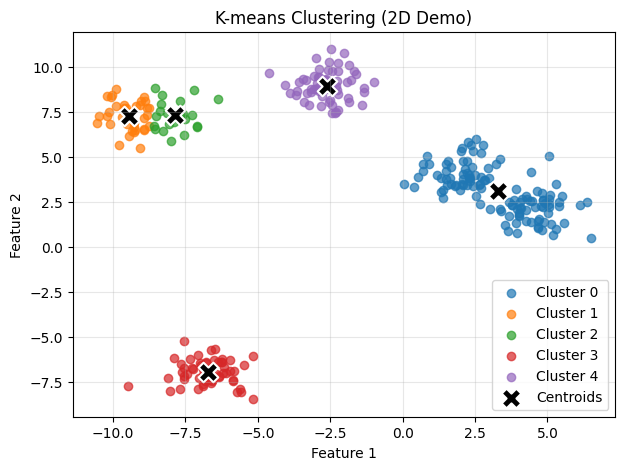

In [ ]:
# =====================================================================
# 🧪 DEMO: Chạy thử với dữ liệu mẫu
# =====================================================================
if __name__ == "__main__":
    # Tạo dữ liệu giả lập: 3 cụm hình cầu trong không gian 2D
    from sklearn.datasets import make_blobs

    X_demo, y_true = make_blobs(
        n_samples=300,
        centers=5,
        n_features=2,
        cluster_std=0.8,
        random_state=42
    )

    # Khởi tạo model
    model = KMeansClustering(X=X_demo, n_clusters=5, random_state=42)

    # Fit
    model.fit(max_iters=200, tol=1e-4, verbose=True)

    # Kết quả
    print(f"\nSố vòng lặp thực tế: {model.n_iter_}")
    print(f"Inertia (WCSS): {model.inertia_:.4f}")

    # Predict một vài điểm mới
    X_new = np.array([[0, 0], [5, 5], [5, 4]])
    print(f"Nhãn dự đoán cho X_new: {model.predict(X_new)}")

    # Vẽ
    model.plot(title="K-means Clustering (2D Demo)")

In [ ]:
from sklearn.cluster import KMeans

model = KMeans(n_clusters=5, random_state=42, n_init= 'auto')
model.fit(X_demo)
model.predict(X_new)

array([4, 0, 0], dtype=int32)